In [1]:

%load_ext autoreload
%autoreload 2

import sys
from scipy.stats import sem

file_path = '/Users/michaelfinch/CA1-interneuron-GLM' #Mac
#file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM"

sys.path.append(file_path)

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from finding_weights_over_NDNF_utils import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=file_path, name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=file_path, name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=file_path, name="EC_GLM", new_NDNF=False)

GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path=file_path, name="NDNF_E1A1B", new_NDNF=True)


# fixed_residual_activity_dict_NDNF_newest = {}
# for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
#     if 17 < idx < 31:
#         fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

# fixed_activity_dict_NDNF_newest = {}
# for idx, animal in enumerate(activity_dict_NDNF_newest):
#     if 17 < idx < 31:
#         fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]



In [3]:


fixed_factors_dict_NDNF_newest = subset_factors(factors_dict_NDNF_newest)
fixed_residual_activity_dict_NDNF_newest = subset_factors(residual_activity_dict_NDNF_newest)
fixed_activity_dict_NDNF_newest = subset_factors(activity_dict_NDNF_newest)



NameError: name 'subset_factors' is not defined

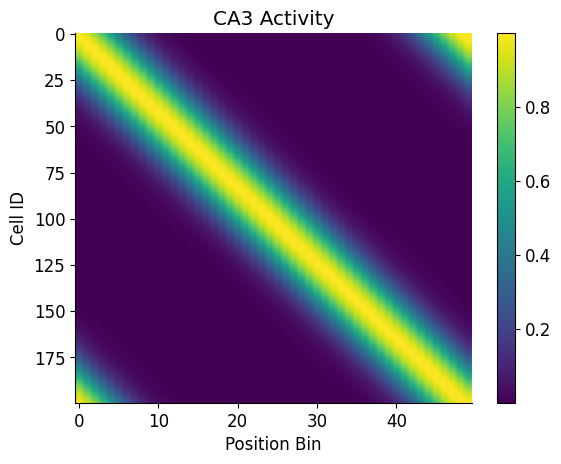

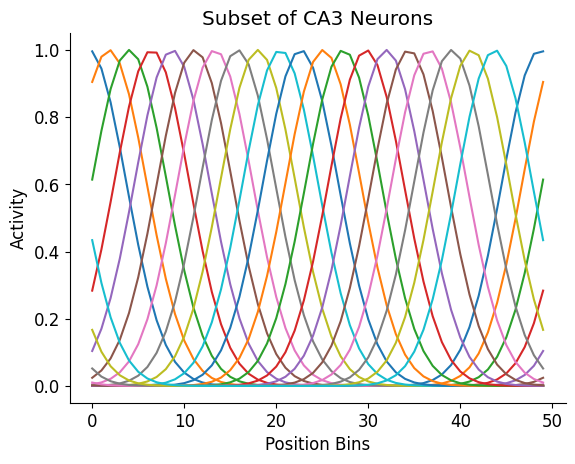

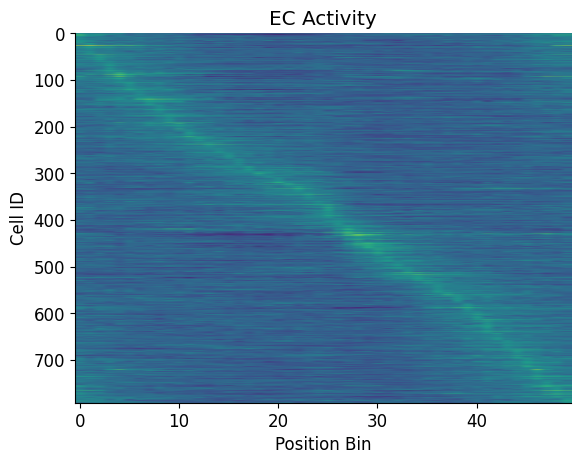

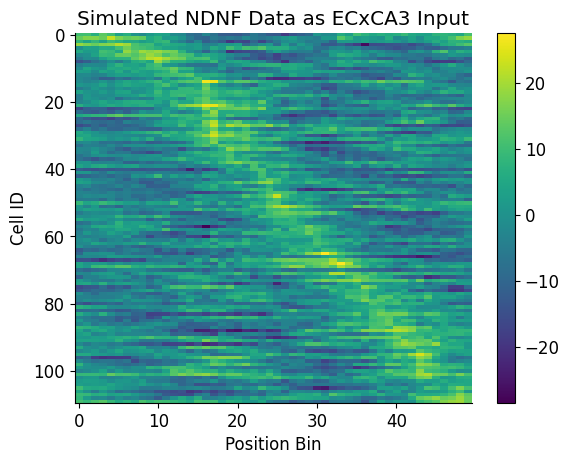

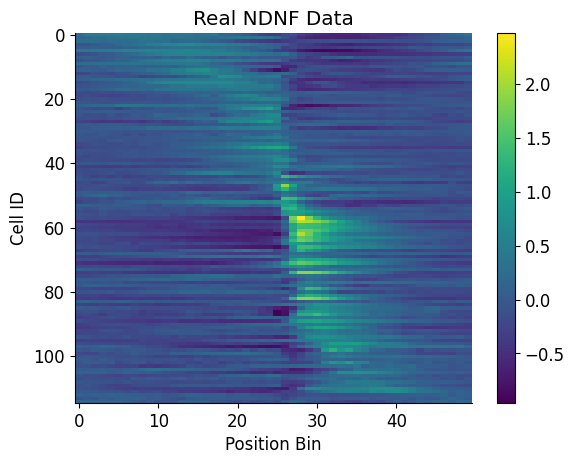

In [ ]:


ca3_vs_position_all_cells_array = get_CA3_data(track_length = 180, num_cells=200)
plot_CA3(ca3_vs_position_all_cells_array)


EC_residuals_array = get_plot_EC(residual_activity_dict_EC)
    

NDNF_activity_list = get_synthetic_NDNF(EC_residuals_array, dist_type = "normal")
NDNF_activity_array = np.array(NDNF_activity_list)
sorted_NDNF_activity_array = np.argsort(np.argmax(NDNF_activity_array, axis=1))

plt.imshow(NDNF_activity_array[sorted_NDNF_activity_array, :], aspect='auto')
plt.title("Simulated NDNF Data as ECxCA3 Input")
plt.ylabel("Cell ID")
plt.xlabel("Position Bin")
plt.colorbar()
plt.show()

real_NDNF_list = []

for animal in fixed_residual_activity_dict_NDNF_newest:
    for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
        real_NDNF_list.append(np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1))
        
real_NDNF_array = np.array(real_NDNF_list)
sorted_real_NDNF_array = np.argsort(np.argmax(real_NDNF_array, axis=1))

plt.imshow(real_NDNF_array[sorted_real_NDNF_array, :], aspect='auto')
plt.title("Real NDNF Data")
plt.ylabel("Cell ID")
plt.xlabel("Position Bin")
plt.colorbar()
plt.show()



In [ ]:
#### truncated to the first 58 trials 




def fit_GLM2(EC_data_array, neuron_activity_flat, regression='linear', alphas=None):
    
    design_matrix_X = EC_data_array.T
    
    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    neuron_predicted_activity = model.predict(design_matrix_X)
    
    return model 




In [9]:
def get_EC_data_array(residual_activity_dict_EC):
    min_val = 1000
    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            if residual_activity_dict_EC[animal][cell].shape[1] < min_val:
                min_val = residual_activity_dict_EC[animal][cell].shape[1] 

    EC_data_list = []

    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            EC_truncated = residual_activity_dict_EC[animal][cell][:,:min_val]
            EC_data_list.append(EC_truncated.flatten())

    EC_data_array = np.array(EC_data_list)

    return EC_data_array

EC_data_array = get_EC_data_array(residual_activity_dict_EC)

In [10]:


def get_CA3_data_array(ca3_vs_position_all_cells_array):
    num_trials = 58
    CA3_data_list = []

    for i in range(ca3_vs_position_all_cells_array.shape[0]):
        data = ca3_vs_position_all_cells_array[i, :] 
        
        tiled_data = np.tile(data[:, np.newaxis], (1, num_trials))
        
    #     plt.imshow(tiled_data.T, aspect='auto')
    #     plt.show()
        
        CA3_data_list.append(tiled_data.flatten())
        
    CA3_data_array = np.array(CA3_data_list)

    return CA3_data_array


CA3_data_array = get_CA3_data_array(ca3_vs_position_all_cells_array)

In [ ]:
### get SST data arroy 

def get_SST_data_array(activity_dict_SST):

    min_val = 1000
    for animal in activity_dict_SST:
        for cell in activity_dict_SST[animal]:
            if activity_dict_SST[animal][cell].shape[1] < min_val:
                min_val = activity_dict_SST[animal][cell].shape[1] 

    SST_data_list = []

    for animal in residual_activity_dict_SST:
        for cell in residual_activity_dict_SST[animal]:
            SST_data_list.append(residual_activity_dict_SST[animal][cell][:,:min_val].flatten())
            
    SST_data_array = np.array(SST_data_list)
    return SST_data_array

SST_data_array = get_SST_data_array(activity_dict_SST)


In [12]:
### EC + CA3 data 

EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
print(EC_CA3_data_array.shape)

(992, 2900)


In [13]:
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
print(EC_CA3_data_array.shape)

(992, 2900)


In [14]:
EC_SST_data_array = np.concatenate([EC_data_array, SST_data_array], axis=0)
print(EC_SST_data_array.shape)

(867, 2900)


In [15]:
CA3_SST_data_array = np.concatenate([CA3_data_array, SST_data_array], axis=0)
print(CA3_SST_data_array.shape)

(275, 2900)


In [16]:
EC_CA3_SST_data_array = np.concatenate([EC_data_array, CA3_data_array, SST_data_array], axis=0)
print(EC_CA3_SST_data_array.shape)

(1067, 2900)


In [290]:
EC_data_array.shape

(792, 2900)

In [ ]:
def get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge"):
    model_EC = {}
    for animal in fixed_residual_activity_dict_NDNF_newest:
        cell_model_EC = {}
        for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
            neuron_activity = fixed_residual_activity_dict_NDNF_newest[animal][cell][:,:58]
            neuron_activity_flat = neuron_activity.flatten()
            model_NDNF = fit_GLM2(EC_data_array, neuron_activity_flat, regression=reg_type, alphas=None)
            cell_model_EC[cell] = model_NDNF
        model_EC[animal] = cell_model_EC
        
    return model_EC


In [ ]:
model_EC_just_CA3 = get_model_dict(CA3_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_just_SST = get_model_dict(SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_just_EC = get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")


In [ ]:
model_EC_EC_CA3 = get_model_dict(EC_CA3_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")


In [ ]:
model_EC_EC_SST = get_model_dict(EC_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")



In [ ]:
model_EC_CA3_SST = get_model_dict(CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")



In [ ]:
model_EC_EC_CA3_SST = get_model_dict(EC_CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")



In [ ]:


def get_MSE_cell_type(model_EC_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array):
    MSE_list = []
    coefficients_list = []
    for animal in model_EC_just_SST:
        for cell in model_EC_just_SST[animal]:
            model = model_EC_just_SST[animal][cell]
            neuron_activity = fixed_residual_activity_dict_NDNF_newest[animal][cell][:,:58]
            coefficients = model.coef_
            coefficients_list.append(coefficients)
            neuron_predicted_activity = model.predict(SST_data_array.T)
            predicted_NDNF = neuron_predicted_activity.reshape(neuron_activity.shape)
            MSE = np.mean(np.square(predicted_NDNF - neuron_activity))
            MSE_list.append(MSE) 
            
    return MSE_list, coefficients_list


In [ ]:
MSE_list_just_SST, coefficients_list_just_SST = get_MSE_cell_type(model_EC_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array)
MSE_list_just_EC, coefficients_list_just_EC = get_MSE_cell_type(model_EC_just_EC, fixed_residual_activity_dict_NDNF_newest, EC_data_array)
MSE_list_just_CA3, coefficients_list_just_CA3 = get_MSE_cell_type(model_EC_just_CA3, fixed_residual_activity_dict_NDNF_newest, CA3_data_array)

In [ ]:
MSE_list_EC_CA3, coefficients_list_EC_CA3 = get_MSE_cell_type(model_EC_EC_CA3, fixed_residual_activity_dict_NDNF_newest, EC_CA3_data_array)

In [ ]:
MSE_list_EC_SST, coefficients_list_EC_SST = get_MSE_cell_type(model_EC_EC_SST, fixed_residual_activity_dict_NDNF_newest, EC_SST_data_array)

In [ ]:
MSE_list_CA3_SST, coefficients_list_CA3_SST = get_MSE_cell_type(model_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, CA3_SST_data_array)

In [ ]:
MSE_list_EC_CA3_SST, coefficients_list_CA3_SST = get_MSE_cell_type(model_EC_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, EC_CA3_SST_data_array)

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_5871/2046271118.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


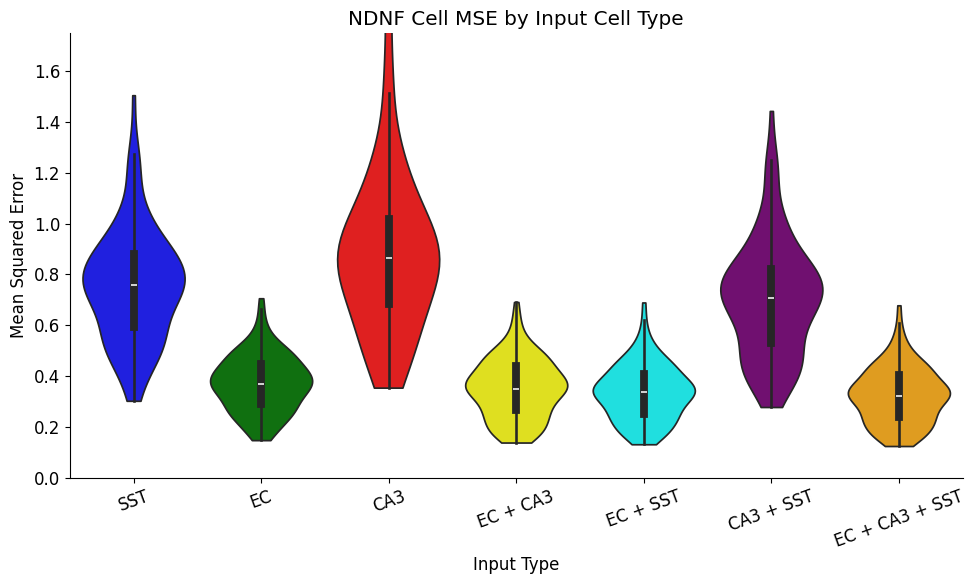

In [ ]:

###### make sure that each datapoint is a cell 

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Create DataFrame
df = pd.DataFrame({
    "MSE": (
        MSE_list_just_SST +
        MSE_list_just_EC +strip
        MSE_list_just_CA3 +
        MSE_list_EC_CA3 +
        MSE_list_EC_SST +
        MSE_list_CA3_SST +
        MSE_list_EC_CA3_SST
    ),
    "Input": (
        ["SST"] * len(MSE_list_just_SST) +
        ["EC"] * len(MSE_list_just_EC) +
        ["CA3"] * len(MSE_list_just_CA3) +
        ["EC + CA3"] * len(MSE_list_EC_CA3) +
        ["EC + SST"] * len(MSE_list_EC_SST) +
        ["CA3 + SST"] * len(MSE_list_CA3_SST) +
        ["EC + CA3 + SST"] * len(MSE_list_EC_CA3_SST)
    )
})

# Step 2: Define custom color palette
custom_palette = {
    "SST": "blue",
    "EC": "green",
    "CA3": "red",
    "EC + CA3": "yellow",
    "EC + SST": "cyan",
    "CA3 + SST": "purple",
    "EC + CA3 + SST": "orange"
}

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)
plt.title("NDNF Cell MSE by Input Cell Type")
plt.ylabel("Mean Squared Error")
plt.xlabel("Input Type")
plt.xticks(rotation=20)
plt.ylim(0,1.75)
plt.tight_layout()
plt.show()


In [347]:
#Just do EC -- has all of the useful inofrmation --- train on the early and test on the late 


##### getting the early data 

#### load the cutpoint data 

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)



Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [375]:
fixed_model_dict_NDNF_newest = {20:{}}
for animal in cell_NDNF_model_ranks20_contig_x00[20]:
    if 17 < animal < 31:
        fixed_model_dict_NDNF_newest[20][animal-18] = cell_NDNF_model_ranks20_contig_x00[20][animal]


def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict


cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)


In [493]:
75/5

15.0

In [410]:
def split_data_by_cp(activity_dict_EC, cp_dict_EC):
    early_cp_dict={}
    late_cp_dict={}

    for idx, animal in enumerate(activity_dict_EC):
        early_cell_cp_dict={}
        late_cell_cp_dict={}
        for id, cell in enumerate(activity_dict_EC[animal]):
            data = activity_dict_EC[animal][cell]
            cp = cp_dict_EC[idx][id]
            early_cp = cp[0]
            late_cp = cp[1]
            data_early = data[:,:early_cp]
            data_late = data[:,late_cp:]
            early_cell_cp_dict[cell] = data_early
            late_cell_cp_dict[cell] = data_late

        early_cp_dict[animal] = early_cell_cp_dict
        late_cp_dict[animal] = late_cell_cp_dict

    return early_cp_dict, late_cp_dict



early_cp_dict_EC, late_cp_dict_EC = split_data_by_cp(activity_dict_EC, cp_dict_EC)
early_cp_dict_SST, late_cp_dict_SST = split_data_by_cp(activity_dict_SST, cp_dict_SST)
early_cp_dict_NDNF, late_cp_dict_NDNF = split_data_by_cp(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)



In [459]:

def get_data_array_learning_split(activity_dict_EC):

    data_list = []
    for animal in activity_dict_EC:
        for cell in activity_dict_EC[animal]:
            data_list.append(activity_dict_EC[animal][cell].shape[1]//5)

        data_dict[animal] = data_dict_cell


    mean_quint = np.mean(data_list)
    mean_quint_int = int(mean_quint)

    early_cp_dict={}
    late_cp_dict={}

    data_early_list = []
    data_late_list = []

    for animal in activity_dict_EC:
        early_cell_cp_dict={}
        late_cell_cp_dict={}
        for cell in activity_dict_EC[animal]:
            data = activity_dict_EC[animal][cell]
            data_early = data[:,:mean_quint_int]
            data_early_list.append(data_early)
            data_late = data[:,-mean_quint_int:]
            data_late_list.append(data_late)

            early_cell_cp_dict[cell] = data_early
            late_cell_cp_dict[cell] = data_late

        early_cp_dict[animal] = early_cell_cp_dict
        late_cp_dict[animal] = late_cell_cp_dict

    data_early_array = np.array(data_early_list)
    data_late_array = np.array(data_late_list)

    return data_early_array, data_late_array



data_early_array_EC, data_late_array_EC = get_data_array_learning_split(activity_dict_EC)
data_early_array_SST, data_late_array_SST = get_data_array_learning_split(activity_dict_SST)
data_early_array_NDNF, data_late_array_NDNF = get_data_array_learning_split(fixed_activity_dict_NDNF_newest)






In [471]:
data_early_array_EC, data_late_array_EC = get_data_array_learning_split(activity_dict_EC)
data_early_array_SST, data_late_array_SST = get_data_array_learning_split(activity_dict_SST)
data_early_array_NDNF, data_late_array_NDNF = get_data_array_learning_split(fixed_activity_dict_NDNF_newest)

data_late_array_EC.shape

(792, 50, 15)

In [496]:
def get_model_dict_early_late(EC_data_array, activity_dict_EC, reg_type="ridge"):

    # counter=0
    model_EC_dict = {}
    for animal in activity_dict_EC:
        cell_model_EC = {}
        for cell in activity_dict_EC[animal]:
            # if counter <75:
            num_trials = EC_data_array[0].shape[1]

            data_early_array_EC_flat = EC_data_array.reshape(EC_data_array.shape[0], -1)

            neuron_activity = activity_dict_EC[animal][cell][:,:num_trials]
            neuron_activity_flat = neuron_activity.flatten()
            model_EC = fit_GLM2(data_early_array_EC_flat, neuron_activity_flat, regression=reg_type, alphas=None)
            cell_model_EC[cell] = model_EC
                # counter+=1
        model_EC_dict[animal] = cell_model_EC
        
    return model_EC_dict

model_EC_dict_early = get_model_dict_early_late(data_early_array_EC, activity_dict_EC, reg_type="ridge")
model_SST_dict_early = get_model_dict_early_late(data_early_array_SST, activity_dict_SST, reg_type="ridge")
model_NDNF_dict_early = get_model_dict_early_late(data_early_array_NDNF, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")




def get_MSE_cell_type2(model_EC_dict_early, activity_dict_EC, data_late_array_EC):
    # counter=0
    MSE_list = []
    coefficients_list = []
    for animal in model_EC_dict_early:
        for cell in model_EC_dict_early[animal]:
            # if counter < 75:
            model = model_EC_dict_early[animal][cell]
            index = data_late_array_EC.shape[2]
            neuron_activity = activity_dict_EC[animal][cell][:,-index:]
            coefficients = model.coef_
            coefficients_list.append(coefficients)
            data_late_array_EC_flat = data_late_array_EC.reshape(data_late_array_EC.shape[0], -1)
            neuron_predicted_activity = model.predict(data_late_array_EC_flat.T)
            predicted_NDNF = neuron_predicted_activity.reshape(neuron_activity.shape)
            MSE = np.mean(np.square(predicted_NDNF - neuron_activity))
            MSE_list.append(MSE) 
                # counter+=1
            
    return MSE_list, coefficients_list




MSE_list_EC_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, activity_dict_EC, data_late_array_EC)
MSE_list_SST_early, coefficients_list_SST_early = get_MSE_cell_type2(model_SST_dict_early, activity_dict_SST, data_late_array_SST)
MSE_list_NDNF_early, coefficients_list_NDNF_early = get_MSE_cell_type2(model_NDNF_dict_early, fixed_residual_activity_dict_NDNF_newest, data_late_array_NDNF)



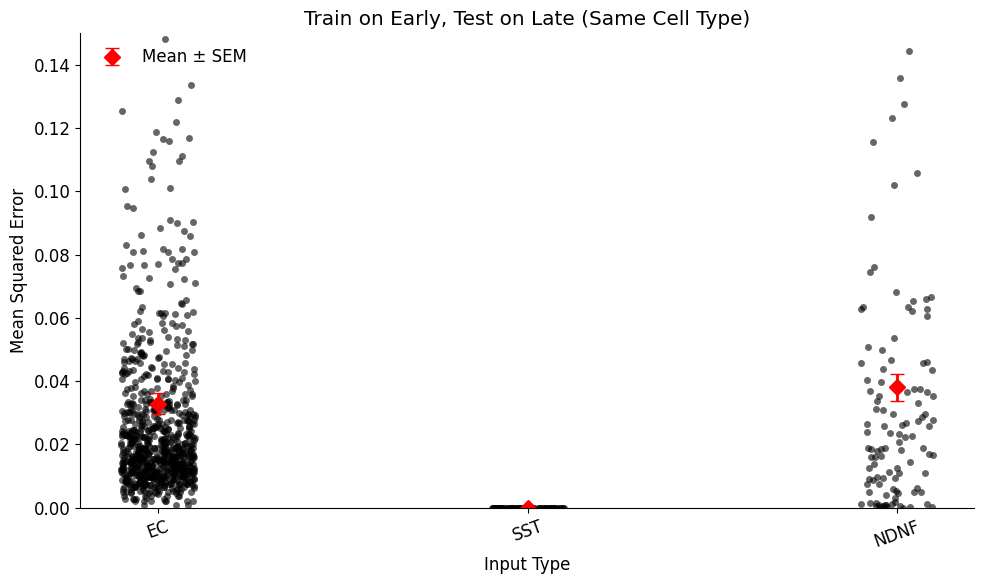

In [497]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create the DataFrame
df = pd.DataFrame({
    "MSE": (
        MSE_list_EC_early +
        MSE_list_SST_early +
        MSE_list_NDNF_early 
    ),
    "Input": (
        ["EC"] * len(MSE_list_EC_early) +
        ["SST"] * len(MSE_list_SST_early) +
        ["NDNF"] * len(MSE_list_NDNF_early) 
    )
})

plt.figure(figsize=(10, 6))

# Plot individual data points in black
sns.stripplot(x="Input", y="MSE", data=df, 
              jitter=True, color="black", alpha=0.6, zorder=1)

# Compute mean and SEM
group_stats = df.groupby("Input")["MSE"].agg(["mean", "sem"]).reset_index()

# Determine category order as used by seaborn
input_order = df["Input"].unique()
x_positions = np.arange(len(input_order))

# Plot red diamonds with error bars
for i, input_type in enumerate(input_order):
    mean = group_stats.loc[group_stats["Input"] == input_type, "mean"].values[0]
    sem = group_stats.loc[group_stats["Input"] == input_type, "sem"].values[0]
    plt.errorbar(i, mean, yerr=sem, fmt='D', color='red', 
                 capsize=5, markersize=8, elinewidth=2, label="Mean ± SEM" if i == 0 else "", zorder=2)

# Final polish
plt.xticks(ticks=x_positions, labels=input_order, rotation=20)
plt.xlabel("Input Type")
plt.ylabel("Mean Squared Error")
plt.title("Train on Early, Test on Late (Same Cell Type)")
plt.ylim(0, 0.15)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:



def get_model_dict_early_late(EC_data_array, fixed_activity_dict_NDNF_newest, reg_type="ridge"):

    model_EC_dict = {}
    for animal in fixed_activity_dict_NDNF_newest:
        cell_model_EC = {}
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            num_trials = EC_data_array[0].shape[1]

            data_early_array_EC_flat = EC_data_array.reshape(EC_data_array.shape[0], -1)

            neuron_activity = fixed_activity_dict_NDNF_newest[animal][cell][:,:num_trials]
            neuron_activity_flat = neuron_activity.flatten()
            model_EC = fit_GLM2(data_early_array_EC_flat, neuron_activity_flat, regression=reg_type, alphas=None)
            cell_model_EC[cell] = model_EC
        model_EC_dict[animal] = cell_model_EC
        
    return model_EC_dict

model_EC_dict_early = get_model_dict_early_late(data_early_array_EC, fixed_activity_dict_NDNF_newest, reg_type="ridge")
### input will be EC early and I want to compare it -- have it predice NDNF early 
model_SST_dict_early = get_model_dict_early_late(data_early_array_SST, activity_dict_SST, reg_type="ridge")
#### the same thing for SST


def get_MSE_cell_type2(model_EC_dict_early, activity_dict_EC, data_late_array_EC, predict_early_or_late="early"):
    MSE_list = []
    coefficients_list = []
    for animal in model_EC_dict_early:
        for cell in model_EC_dict_early[animal]:
            model = model_EC_dict_early[animal][cell]
            index = data_late_array_EC.shape[2]
            if predict_early_or_late == "early":
                neuron_activity = activity_dict_EC[animal][cell][:,:index]
            else:
                neuron_activity = activity_dict_EC[animal][cell][:,-index:]
            coefficients = model.coef_
            coefficients_list.append(coefficients)
            data_late_array_EC_flat = data_late_array_EC.reshape(data_late_array_EC.shape[0], -1)
            neuron_predicted_activity = model.predict(data_late_array_EC_flat.T)
            predicted_NDNF = neuron_predicted_activity.reshape(neuron_activity.shape)
            MSE = np.mean(np.square(predicted_NDNF - neuron_activity))
            MSE_list.append(MSE) 
            
    return MSE_list, coefficients_list

MSE_list_EC_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_NDNF, predict_early_or_late="early")
##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_EC_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_NDNF, predict_early_or_late="late")
###### model trained on early NDNF and EC then how different is the MSE vs the late NDNF 




# MSE_list_SST_early, coefficients_list_SST_early = get_MSE_cell_type2(model_SST_dict_early, activity_dict_SST, data_late_array_SST)
# MSE_list_NDNF_early, coefficients_list_NDNF_early = get_MSE_cell_type2(model_NDNF_dict_early, fixed_residual_activity_dict_NDNF_newest, data_late_array_NDNF)

In [398]:

def get_trunc_data(activity_dict_SST):

    min_val = 1000
    for animal in activity_dict_SST:
        for cell in activity_dict_SST[animal]:
            if activity_dict_SST[animal][cell].shape[1] < min_val:
                min_val = activity_dict_SST[animal][cell].shape[1] 

    SST_data_list = []

    for animal in activity_dict_SST:
        for cell in activity_dict_SST[animal]:
            SST_data_list.append(activity_dict_SST[animal][cell][:,:min_val].flatten())
            
    SST_data_array = np.array(SST_data_list)
    return SST_data_array, min_val

early_EC_array, min_val_EC_early = get_trunc_data(early_cp_dict_EC)
late_EC_array, min_val_EC_late = get_trunc_data(late_cp_dict_EC)

early_SST_array, min_val_SST_early = get_trunc_data(early_cp_dict_SST)
late_SST_array, min_val_SST_late = get_trunc_data(late_cp_dict_SST)






In [399]:
def get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, min_val, reg_type="ridge"):
    model_EC = {}
    for animal in fixed_residual_activity_dict_NDNF_newest:
        cell_model_EC = {}
        for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
            neuron_activity = fixed_residual_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            neuron_activity_flat = neuron_activity.flatten()
            model_NDNF = fit_GLM2(EC_data_array, neuron_activity_flat, regression=reg_type, alphas=None)
            cell_model_EC[cell] = model_NDNF
        model_EC[animal] = cell_model_EC
        
    return model_EC


model_EC_dict_early = get_model_dict(early_EC_array, activity_dict_EC, min_val_EC_early, reg_type="ridge")


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Create DataFrame
df = pd.DataFrame({
    "MSE": (
        MSE_list_just_SST +
        MSE_list_just_EC +strip
        MSE_list_just_CA3 +
        MSE_list_EC_CA3 +
        MSE_list_EC_SST +
        MSE_list_CA3_SST +
        MSE_list_EC_CA3_SST
    ),
    "Input": (
        ["SST"] * len(MSE_list_just_SST) +
        ["EC"] * len(MSE_list_just_EC) +
        ["CA3"] * len(MSE_list_just_CA3) +
        ["EC + CA3"] * len(MSE_list_EC_CA3) +
        ["EC + SST"] * len(MSE_list_EC_SST) +
        ["CA3 + SST"] * len(MSE_list_CA3_SST) +
        ["EC + CA3 + SST"] * len(MSE_list_EC_CA3_SST)
    )
})

# Step 2: Define custom color palette
custom_palette = {
    "SST": "blue",
    "EC": "green",
    "CA3": "red",
    "EC + CA3": "yellow",
    "EC + SST": "cyan",
    "CA3 + SST": "purple",
    "EC + CA3 + SST": "orange"
}

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)
plt.title("NDNF Cell MSE by Input Cell Type")
plt.ylabel("Mean Squared Error")
plt.xlabel("Input Type")
plt.xticks(rotation=20)
plt.ylim(0,1.75)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

def fit_log_reg(neural_activity_sup_bef_V1, y, n_splits=10):
  activity_list = []
  for i in range(neural_activity_sup_bef_V1.shape[0]):
    flat_activity = neural_activity_sup_bef_V1[i,:,:].flatten()
    activity_list.append(flat_activity)

  X = np.array(activity_list).T
  # X = X[:,:100]

  X_scaled = (X - np.min(X)) / (np.max(X) - np.min(X))

  y_flat = y.flatten()

  log_reg = LogisticRegression(penalty=None, max_iter=1000)

  accuracies = cross_val_score(log_reg, X_scaled, y_flat, cv=n_splits)

  return accuracies
# accuracies = fit_log_reg(neural_activity_sup_bef_V1, lick_data_array_before_sup, n_splits=10)
# accuracies = fit_log_reg(NDNF_activity_array, lick_data_array_before_sup, n_splits=10)
# print(accuracies)

In [ ]:
def get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Licks'):
    lick_list = []
    for animal in fixed_factors_dict_NDNF_newest:
        lick_list.append(fixed_factors_dict_NDNF_newest[animal][vars][:,:n_trials])

    lick_array = np.array(lick_list)
    return lick_array

def setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):  
    
    shape_list =[]
    for animal in fixed_factors_dict_NDNF_newest:
        shape_list.append(fixed_factors_dict_NDNF_newest[animal]['Licks'].shape[1])

    n_trials = np.min(shape_list)

    EC = {}
    for idx, animal in enumerate(fixed_activity_dict_NDNF_newest):
        NDNF_list = []
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            NDNF_list.append(fixed_activity_dict_NDNF_newest[animal][cell][:,:n_trials])

        NDNF_array = np.array(NDNF_list)
        EC[idx] = NDNF_array

    NDNF_activity_array = np.array(NDNF_list)


    lick_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Licks')
    reward_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Reward_loc')
    velocity_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Velocity')

    return EC, lick_array, reward_array, velocity_array




from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

def fit_log_reg(neural_activity_sup_bef_V1, y, n_splits=10):
  activity_list = []
  for i in range(neural_activity_sup_bef_V1.shape[0]):
    flat_activity = neural_activity_sup_bef_V1[i,:,:].flatten()
    activity_list.append(flat_activity)

  X = np.array(activity_list).T
  # X = X[:,:100]

  y_flat = y.flatten()

  log_reg = LogisticRegression(penalty=None, max_iter=1000)

  accuracies = cross_val_score(log_reg, X, y_flat, cv=n_splits)
  return accuracies




# ###### will have to get a different value for every animal 
# NDNF_activity_array, NDNF_lick_array, NDNF_reward_array, NDNF_velocity_array = setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)

# accuracies = fit_log_reg(NDNF_activity_array, NDNF_lick_array[0,:,:].astype(int), n_splits=7)





In [281]:
NDNF_dict, NDNF_lick_array, NDNF_reward_array, NDNF_velocity_array = setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
SST_dict, SST_lick_array, SST_reward_array, SST_velocity_array = setup_log_reg(activity_dict_SST, factors_dict_SST)
EC_dict, EC_lick_array, EC_reward_array, EC_velocity_array = setup_log_reg(activity_dict_EC, factors_dict_EC)




In [ ]:
######## decoding logistic regression 

(13, 50, 100)

In [288]:
def get_accuracy_per_animal(EC, NDNF_reward_array, n_splits=7):
    accuracy_dict = {}
    for i in range(len(EC)):
        accuracies = fit_log_reg(EC[i], NDNF_reward_array[i,:,:].astype(int), n_splits=n_splits)
        accuracy_dict[i] = accuracies
    
    return accuracy_dict

def get_accuracies_per_celltype(NDNF_dict, EC_dict, SST_dict, NDNF_reward_array, EC_reward_array, SST_reward_array, n_splits=5):

    accuracy_dict_NDNF = get_accuracy_per_animal(NDNF_dict, NDNF_reward_array, n_splits=n_splits)

    EC_reward_binary = (EC_reward_array > 0).astype(int)

    accuracy_dict_EC = get_accuracy_per_animal(EC_dict, EC_reward_binary, n_splits=n_splits)

    accuracy_dict_SST = get_accuracy_per_animal(SST_dict, SST_reward_array, n_splits=n_splits)

    return accuracy_dict_NDNF, accuracy_dict_EC, accuracy_dict_SST




accuracy_dict_NDNF_reward, accuracy_dict_EC_reward, accuracy_dict_SST_reward = get_accuracies_per_celltype(NDNF_dict, EC_dict, SST_dict, NDNF_reward_array, EC_reward_array, SST_reward_array, n_splits=3)



In [289]:
accuracy_dict_NDNF_lick, accuracy_dict_EC_lick, accuracy_dict_SST_lick = get_accuracies_per_celltype(NDNF_dict, EC_dict, SST_dict, NDNF_lick_array, EC_lick_array, SST_lick_array)

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  Fil

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py", line 1335, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 classes in the data

In [287]:
for i in range(NDNF_lick_array.shape[0]):
    lick_animal_data = NDNF_lick_array[i,:,:]
    print(np.any(np.unique(lick_animal_data)))



True
True
True
True
True
True
True
True
True
True
True
True
True


In [160]:


def get_accuracy_list(accuracy_dict_NDNF):
    mean_accuracy_per_animal_list_NDNF = []
    for animal in accuracy_dict_NDNF:
        mean_accuracy_per_animal_list_NDNF.append(np.mean(accuracy_dict_NDNF[animal])*100)
    return mean_accuracy_per_animal_list_NDNF

mean_accuracy_per_animal_list_NDNF = get_accuracy_list(accuracy_dict_NDNF)
mean_accuracy_per_animal_list_SST = get_accuracy_list(accuracy_dict_SST)
mean_accuracy_per_animal_list_EC = get_accuracy_list(accuracy_dict_EC)


/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_5871/2894478264.py:21: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.pointplot(x='Group', y='Accuracy', hue='Group', data=df, color='red', errorbar='sd', markers='d', err_kws={'linewidth': 1.5})


ANOVA: F = 10.63, p = 0.0004
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    EC   NDNF   2.9238 0.0007  1.2009 4.6466   True
    EC    SST   2.9838  0.001  1.1728 4.7948   True
  NDNF    SST     0.06 0.9949 -1.4858 1.6058  False
---------------------------------------------------


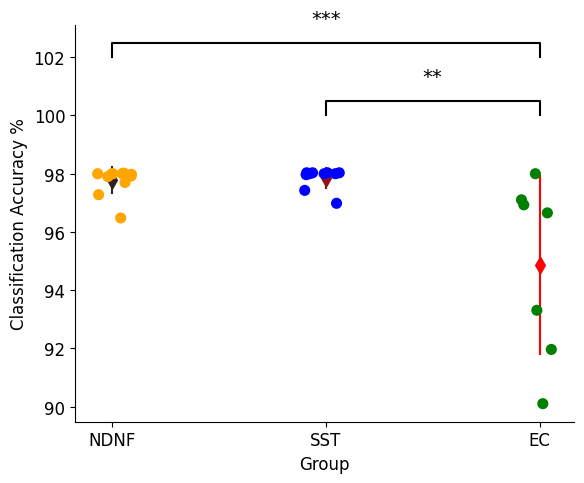

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# --- Your data ---
ndnf = mean_accuracy_per_animal_list_NDNF
sst = mean_accuracy_per_animal_list_SST
ec = mean_accuracy_per_animal_list_EC

# Combine into a DataFrame
data = ndnf + sst + ec
groups = (['NDNF'] * len(ndnf)) + (['SST'] * len(sst)) + (['EC'] * len(ec))
df = pd.DataFrame({'Group': groups, 'Accuracy': data})

# --- Plot ---
plt.figure(figsize=(6, 5))
sns.stripplot(x='Group', y='Accuracy', hue='Group', data=df, jitter=True, size=8, palette={'NDNF':'orange', 'SST':'blue', 'EC':'green'})
sns.pointplot(x='Group', y='Accuracy', hue='Group', data=df, color='red', errorbar='sd', markers='d', err_kws={'linewidth': 1.5})

plt.ylabel("Classification Accuracy %")

# --- ANOVA ---
f_val, p_val = f_oneway(ndnf, sst, ec)
print(f"ANOVA: F = {f_val:.2f}, p = {p_val:.4f}")

# --- Tukey HSD post-hoc ---
tukey = pairwise_tukeyhsd(endog=df['Accuracy'], groups=df['Group'], alpha=0.05)
print(tukey)

# --- Add significance stars manually ---
# Get means per group for y positions
means = df.groupby('Group')['Accuracy'].mean().to_dict()
y_offset = 2

# Helper function to add stars
def add_star(x1, x2, y, star, y_offset = 0.5):
    plt.plot([x1, x1, x2, x2], [y, y+y_offset, y+y_offset, y], lw=1.5, color='black')
    plt.text((x1 + x2) / 2, y + y_offset + 0.5, star, ha='center', va='bottom', fontsize=14)

# Get Tukey HSD results table as a DataFrame
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])


custom_y_locs = {
    ('NDNF', 'SST'): 85,
    ('NDNF', 'EC'): 102,
    ('SST', 'EC'): 100
}

# Format the group names for matching
pairs = [('NDNF', 'SST'), ('NDNF', 'EC'), ('SST', 'EC')]
for group1, group2 in pairs:
    row = tukey_df[((tukey_df['group1'] == group1) & (tukey_df['group2'] == group2)) |
                   ((tukey_df['group1'] == group2) & (tukey_df['group2'] == group1))]

    if row.empty:
        continue  # Skip if no match

    p = float(row['p-adj'].values[0])
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = 'n.s.'

    if stars != 'n.s.':
        x1, x2 = ['NDNF', 'SST', 'EC'].index(group1), ['NDNF', 'SST', 'EC'].index(group2)
        # y = max(means[group1], means[group2]) + 3
        y = custom_y_locs.get((group1, group2), 85)
        add_star(x1, x2, y, stars)

plt.tight_layout()
plt.show()


In [ ]:
###### getting behavioral weights over NDNF 


def fit_GLM2(EC_data_array, neuron_activity_flat, regression='linear', alphas=None):
    
    design_matrix_X = EC_data_array.T
    
    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    # neuron_predicted_activity = model.predict(design_matrix_X)
    
    return model 




In [ ]:
for cell in fixed_activity_dict_NDNF_newest[animal]:
    animal_lick_data = fixed_factors_dict_NDNF_newest[animal]['Licks']

In [212]:

def get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):
    NDNF_GLM_models = {}
    design_matrix_dict={}

    for i, animal in enumerate(fixed_activity_dict_NDNF_newest):
        GLM_cell_models = {}
        design_matrix_cell_dict = {}
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            animal_lick_data = fixed_factors_dict_NDNF_newest[animal]['Licks']
            animal_lick_data_flat = animal_lick_data.flatten()

            animal_reward_data = fixed_factors_dict_NDNF_newest[animal]['Reward_loc']
            animal_reward_data_flat = animal_reward_data.flatten()

            animal_velocity_data = fixed_factors_dict_NDNF_newest[animal]['Velocity']
            animal_velocity_data_flat = animal_velocity_data.flatten()

            design_matrix = np.vstack([animal_lick_data_flat, animal_reward_data_flat, animal_velocity_data_flat])
            design_matrix_cell_dict[cell] = design_matrix
            
            neuron_activity = fixed_activity_dict_NDNF_newest[animal][cell]

            neuron_activity_flat = neuron_activity.flatten()

            model = fit_GLM2(design_matrix, neuron_activity_flat, regression='linear', alphas=None)
            
            GLM_cell_models[cell] = model

        NDNF_GLM_models[animal] = GLM_cell_models
        design_matrix_dict[animal] = design_matrix_cell_dict

    return NDNF_GLM_models, design_matrix_dict
    


In [213]:
EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)



In [208]:

def remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, design_matrix_dict_EC, indices_array):
  MSE_list = []

  for idx, neuron in enumerate(GLM_data_dict_sup_bef_V1):
    neuron_data = neural_activity_sup_bef_V1[idx,1:,:]
    weights = GLM_data_dict_sup_bef_V1[neuron]['weights'][indices_array]
    intercept = GLM_data_dict_sup_bef_V1[neuron]['intercept']
    behavioral_correlates_before_slice = behavioral_correlates_before[indices_array,:]
    prediction = (weights @ behavioral_correlates_before_slice) + intercept
    prediction_reshaped = prediction.reshape(neuron_data.shape)
    MSE = np.mean(np.square(neuron_data - prediction_reshaped))
    MSE_list.append(MSE)

  return MSE_list

def get_MSE_lists(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before):
  indices_array = list(np.arange(4))
  MSE_list_all = remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before, indices_array)

  indices_array = list(indices_array[1:])
  MSE_list_minusV = remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before, indices_array)

  indices_array = [0,2,3,4]
  MSE_list_minusL = remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before, indices_array)

  indices_array = [0,1,3,4]
  MSE_list_minusC = remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before, indices_array)

  indices_array = [0,1,2,4]
  MSE_list_minusR = remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before, indices_array)

  indices_array = list(np.arange(3))
  MSE_list_minusT = remove_behaviors_GLM(neural_activity_sup_bef_V1, GLM_data_dict_sup_bef_V1, behavioral_correlates_before, indices_array)

  return MSE_list_all, MSE_list_minusV, MSE_list_minusL, MSE_list_minusC, MSE_list_minusR, MSE_list_minusT

In [278]:
def remove_behaviors_GLM(activity_dict_NDNF, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array):
  MSE_list = []
  prediction_list = []
  weights_list = []

  for animal in NDNF_GLM_models:
    for cell in NDNF_GLM_models[animal]:
    
        neuron_data = activity_dict_NDNF[animal][cell]
        weights = NDNF_GLM_models[animal][cell].coef_
        intercept = NDNF_GLM_models[animal][cell].intercept_

        behavioral_correlates_before_slice = design_matrix_dict_NDNF[animal][cell][indices_array,:]

        prediction = (weights[indices_array] @ behavioral_correlates_before_slice) + intercept
        prediction_reshaped = prediction.reshape(neuron_data.shape)
        prediction_list.append(prediction_reshaped)

        mean_neuron_data = np.mean(neuron_data, axis=1)
        mean_prediction_data = np.mean(prediction_reshaped, axis=1)

        MSE = np.mean(np.square(mean_neuron_data - mean_prediction_data))
        MSE_list.append(MSE)

        weights_list.append(weights)

  return MSE_list, prediction_list, weights_list




In [ ]:
###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

indices_array = np.arange(3)
MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

indices_array = np.arange(3)
MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)

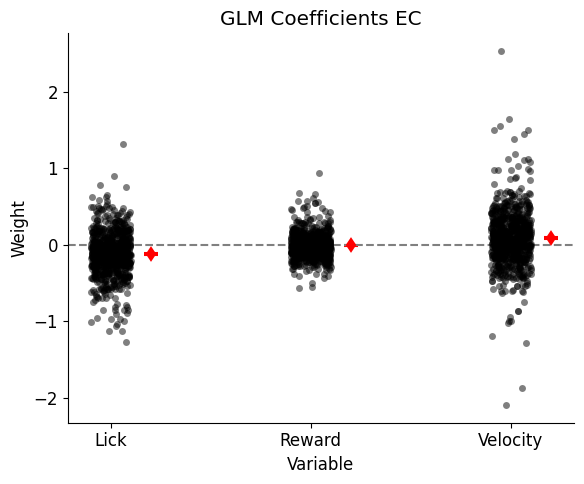

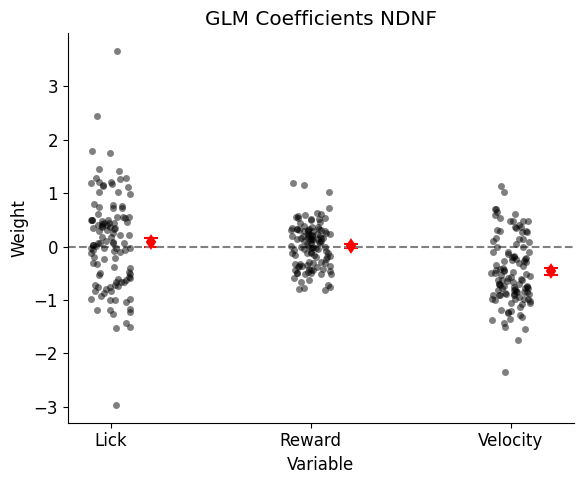

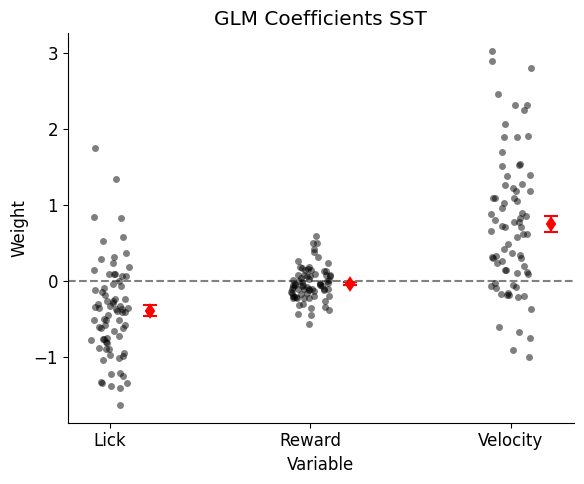

In [242]:

def plot_coefficients_cell_type(weights_list_EC, cell_type="EC"):
    lick_weights = []
    reward_weights = []
    velocity_weights = []

    for i in weights_list_EC:
        lick_weights.append(i[0])
        reward_weights.append(i[1])
        velocity_weights.append(i[2])

    # import matplotlib.pyplot as plt
    # import seaborn as sns
    # import numpy as np
    # import pandas as pd

    # Combine into a DataFrame for easy plotting
    df = pd.DataFrame({
        'Lick': lick_weights,
        'Reward': reward_weights,
        'Velocity': velocity_weights
    })

    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')

    # Plot
    plt.figure(figsize=(6, 5))
    # sns.pointplot(data=df_melted, x='Variable', y='Weight', color='red', join=False, errorbar='sd', markers='d', err_kws={'linewidth': 1.5})
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.5)

    offset=0.2

    variable_names = ['Lick', 'Reward', 'Velocity']
    for i, var in enumerate(variable_names):
        values = df[var]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)

    plt.axhline(0, linestyle='--', color='grey')
    plt.title(f'GLM Coefficients {cell_type}')
    plt.ylabel('Weight')
    plt.tight_layout()
    plt.show()

plot_coefficients_cell_type(weights_list_EC, cell_type="EC")
plot_coefficients_cell_type(weights_list_NDNF, cell_type="NDNF")
plot_coefficients_cell_type(weights_list_SST, cell_type="SST")


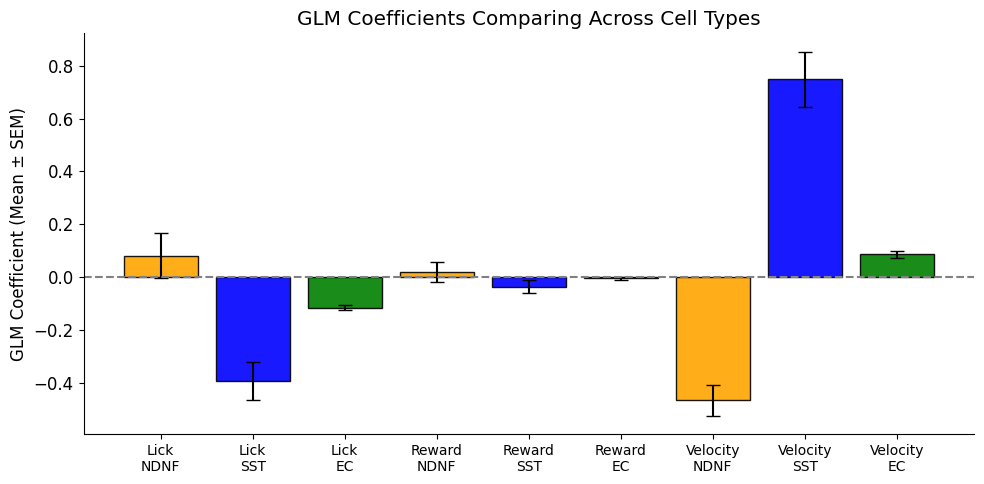

In [239]:
import matplotlib.pyplot as plt
import numpy as np

# --- Assuming these are lists of weight vectors like [[lick, reward, velocity], ...] ---
def extract_weight_lists(weights_list):
    lick = [w[0] for w in weights_list]
    reward = [w[1] for w in weights_list]
    velocity = [w[2] for w in weights_list]
    return lick, reward, velocity

# Extract weight values per group
lick_NDNF, reward_NDNF, velocity_NDNF = extract_weight_lists(weights_list_NDNF)
lick_SST, reward_SST, velocity_SST = extract_weight_lists(weights_list_SST)
lick_EC, reward_EC, velocity_EC = extract_weight_lists(weights_list_EC)

# Combine all groups
data_means = [
    np.mean(lick_NDNF), np.mean(lick_SST), np.mean(lick_EC),
    np.mean(reward_NDNF), np.mean(reward_SST), np.mean(reward_EC),
    np.mean(velocity_NDNF), np.mean(velocity_SST), np.mean(velocity_EC)
]

data_sems = [
    np.std(lick_NDNF)/np.sqrt(len(lick_NDNF)), np.std(lick_SST)/np.sqrt(len(lick_SST)), np.std(lick_EC)/np.sqrt(len(lick_EC)),
    np.std(reward_NDNF)/np.sqrt(len(reward_NDNF)), np.std(reward_SST)/np.sqrt(len(reward_SST)), np.std(reward_EC)/np.sqrt(len(reward_EC)),
    np.std(velocity_NDNF)/np.sqrt(len(velocity_NDNF)), np.std(velocity_SST)/np.sqrt(len(velocity_SST)), np.std(velocity_EC)/np.sqrt(len(velocity_EC)),
]

# Labels
x_labels = ['Lick\nNDNF', 'Lick\nSST', 'Lick\nEC',
            'Reward\nNDNF', 'Reward\nSST', 'Reward\nEC',
            'Velocity\nNDNF', 'Velocity\nSST', 'Velocity\nEC']

# Plot
plt.figure(figsize=(10, 5))
x = np.arange(len(data_means))
colors = ['orange', 'blue', 'green'] * 3

plt.bar(x, data_means, yerr=data_sems, capsize=5, color=colors, edgecolor='black', alpha=0.9)
plt.xticks(x, x_labels, fontsize=10)
plt.ylabel('GLM Coefficient (Mean ± SEM)')
plt.axhline(0, linestyle='--', color='grey')
plt.title('GLM Coefficients Comparing Across Cell Types')
plt.tight_layout()
plt.show()


In [279]:
#####LRV

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)


###### 
indices_array_minusL = [1,2]
MSE_list_EC_minusL, prediction_list_EC_minusL, weights_list_EC_minusL = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_minusL)

MSE_list_NDNF_minusL, prediction_list_NDNF_minusL, weights_list_NDNF_minusL = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_minusL)

MSE_list_SST_minusL, prediction_list_SST_minusL, weights_list_SST_minusL = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_minusL)


indices_array_minusR = [0,2]
MSE_list_EC_minusR, prediction_list_EC_minusR, weights_list_EC_minusR = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_minusR)

MSE_list_NDNF_minusR, prediction_list_NDNF_minusR, weights_list_NDNF_minusR = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_minusR)

MSE_list_SST_minusR, prediction_list_SST_minusR, weights_list_SST_minusR = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_minusR)


indices_array_minusV = [0,1]
MSE_list_EC_minusV, prediction_list_EC_minusV, weights_list_EC_minusV = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_minusV)

MSE_list_NDNF_minusV, prediction_list_NDNF_minusV, weights_list_NDNF_minusV = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_minusV)

MSE_list_SST_minusV, prediction_list_SST_minusV, weights_list_SST_minusV = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_minusV)






/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_5871/148321298.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


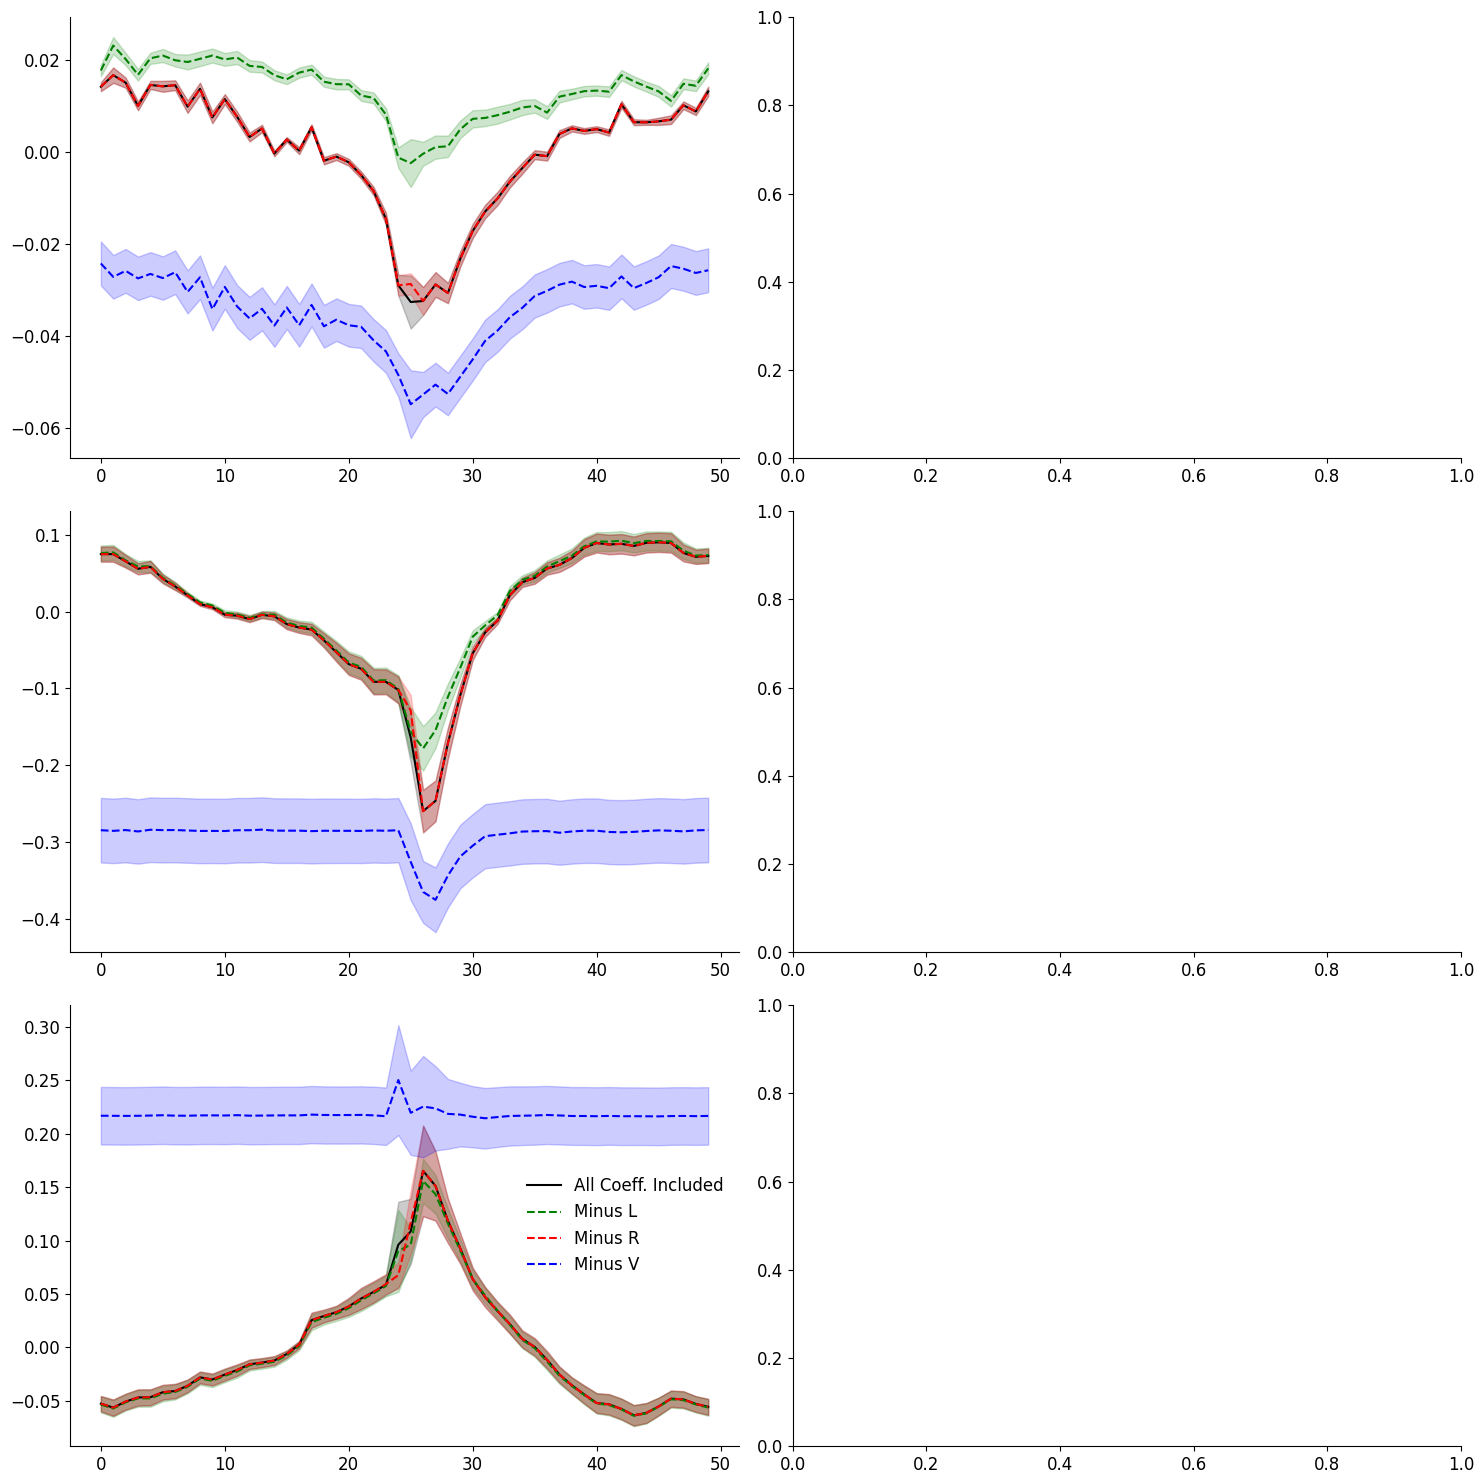

In [ ]:
def get_prediction_lists(prediction_list_EC, prediction_list_EC_minusL, prediction_list_EC_minusR, prediction_list_EC_minusV):
    prediction_overall_list = []
    prediction_minusL_list = []
    prediction_minusR_list = []
    prediction_minusV_list = []

    for i in range(len(prediction_list_EC)):
        prediction_overall_list.append(np.mean(prediction_list_EC[i], axis=1))
        prediction_minusL_list.append(np.mean(prediction_list_EC_minusL[i], axis=1))
        prediction_minusR_list.append(np.mean(prediction_list_EC_minusR[i], axis=1))
        prediction_minusV_list.append(np.mean(prediction_list_EC_minusV[i], axis=1))

    return prediction_overall_list, prediction_minusL_list, prediction_minusR_list, prediction_minusV_list

prediction_overall_list_EC, prediction_minusL_list_EC, prediction_minusR_list_EC, prediction_minusV_list_EC = get_prediction_lists(prediction_list_EC, prediction_list_EC_minusL, prediction_list_EC_minusR, prediction_list_EC_minusV)
prediction_overall_list_NDNF, prediction_minusL_list_NDNF, prediction_minusR_list_NDNF, prediction_minusV_list_NDNF = get_prediction_lists(prediction_list_NDNF, prediction_list_NDNF_minusL, prediction_list_NDNF_minusR, prediction_list_NDNF_minusV)
prediction_overall_list_SST, prediction_minusL_list_SST, prediction_minusR_list_SST, prediction_minusV_list_SST = get_prediction_lists(prediction_list_SST, prediction_list_SST_minusL, prediction_list_SST_minusR, prediction_list_SST_minusV)







def plotting_helper(prediction_overall_list, ax, color="k", label="All Coeff. Included", linestyle="--"):
    prediction_overall_array = np.array(prediction_overall_list)

    mean_overall = np.mean(prediction_overall_array, axis=0)
    sem_overall = sem(prediction_overall_array, axis=0)

    ax.plot(mean_overall, color=color, label=label, linestyle=linestyle)
    ax.fill_between(range(len(mean_overall)), mean_overall - sem_overall, mean_overall + sem_overall,
                    alpha=0.2, color=color)


fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ax = axs[0, 0] 
plotting_helper(prediction_overall_list_EC, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_EC, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_EC, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_EC, ax=ax, color='b', label="Minus V", linestyle='--')
ax.legend()

ax = axs[1, 0] 
plotting_helper(prediction_overall_list_SST, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_SST, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_SST, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_SST, ax=ax, color='b', label="Minus V", linestyle='--')
ax.legend()

ax = axs[2, 0] 
plotting_helper(prediction_overall_list_NDNF, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_NDNF, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_NDNF, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_NDNF, ax=ax, color='b', label="Minus V", linestyle='--')


ax.legend()
plt.tight_layout()

plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

lick_weights = []
reward_weights = []
velocity_weights = []

for i in weights_list_EC:
    lick_weights.append(i[0])
    reward_weights.append(i[1])
    velocity_weights.append(i[2])

input_data = [lick_weights, reward_weights, velocity_weights]
input_keys = ['Lick', 'Reward', 'Velocity']

def plot_coefficients_cell_type(input_data, input_keys, cell_type="EC"):
    

    df = pd.DataFrame({
        'Lick': lick_weights,
        'Reward': reward_weights,
        'Velocity': velocity_weights
    })

    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')

    # Plot
    plt.figure(figsize=(6, 5))
    # sns.pointplot(data=df_melted, x='Variable', y='Weight', color='red', join=False, errorbar='sd', markers='d', err_kws={'linewidth': 1.5})
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.5)

    offset=0.2

    variable_names = ['Lick', 'Reward', 'Velocity']
    for i, var in enumerate(variable_names):
        values = df[var]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)

    plt.axhline(0, linestyle='--', color='grey')
    plt.title(f'GLM Coefficients {cell_type}')
    plt.ylabel('Weight')
    plt.tight_layout()
    plt.show()

plot_coefficients_cell_type(weights_list_EC, cell_type="EC")
plot_coefficients_cell_type(weights_list_NDNF, cell_type="NDNF")
plot_coefficients_cell_type(weights_list_SST, cell_type="SST")


792

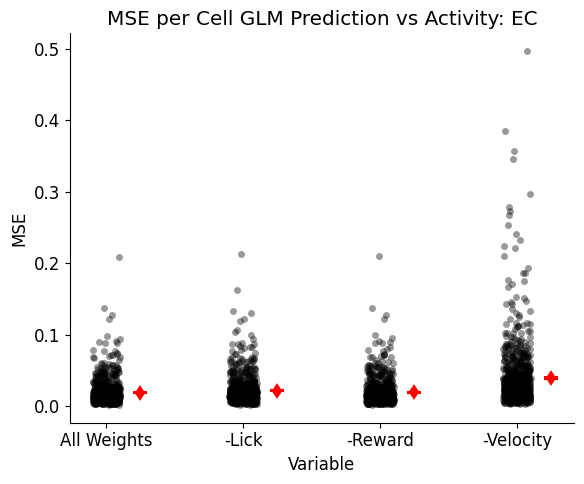

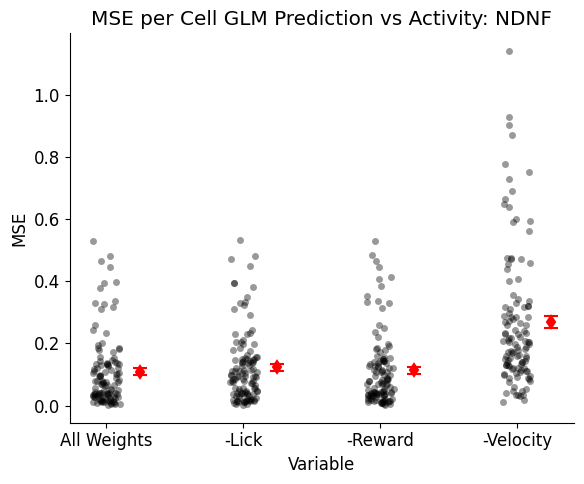

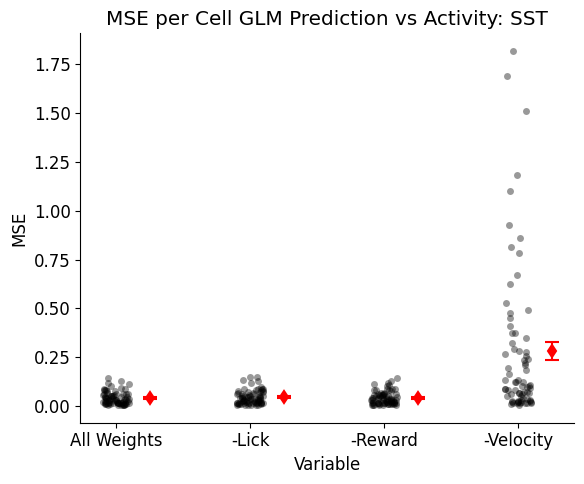

In [ ]:

def plot_coefficients_modular(input_data, input_keys, ax=axs[0,0], cell_type="Cell Type", title_prefix="GLM Coefficients", ylabel="MSE"):
    """
    Plots stripplot + mean ± SEM for input variables.

    Parameters:
    - input_data: list of arrays/lists, one per variable
    - input_keys: list of strings, labels for each variable
    - cell_type: string to appear in the plot title
    - title_prefix: string for title prefix
    """
    assert len(input_data) == len(input_keys), "input_data and input_keys must have same length"
    
    # Combine into a dictionary and then DataFrame
    data_dict = {key: values for key, values in zip(input_keys, input_data)}
    df = pd.DataFrame(data_dict)
    
    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')
    
    # Plot
    plt.figure(figsize=(max(6, len(input_keys)*1.5), 5))
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.4)

    offset = 0.25
    for i, key in enumerate(input_keys):
        values = df[key]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)
    
    ax.set_title(f'{title_prefix}: {cell_type}')
    ax.set_ylabel(ylabel)


# input_data = [MSE_list_EC, MSE_list_EC_minusL, MSE_list_EC_minusR, MSE_list_EC_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="EC", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

# input_data = [MSE_list_NDNF, MSE_list_NDNF_minusL, MSE_list_NDNF_minusR, MSE_list_NDNF_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="NDNF", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

# input_data = [MSE_list_SST, MSE_list_SST_minusL, MSE_list_SST_minusR, MSE_list_SST_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="SST", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")




In [ ]:


input_data = [MSE_list_EC, MSE_list_EC_minusL, MSE_list_EC_minusR, MSE_list_EC_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="EC", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

input_data = [MSE_list_NDNF, MSE_list_NDNF_minusL, MSE_list_NDNF_minusR, MSE_list_NDNF_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="NDNF", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

input_data = [MSE_list_SST, MSE_list_SST_minusL, MSE_list_SST_minusR, MSE_list_SST_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="SST", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

plt.tight_layout()
plt.show()
